# Topic Modeling Bluesky US Election 2024
## LDA topic modeling

**Input:** `Data/1_Bronze/Bluesky/bsky_US_2024_raw.csv`


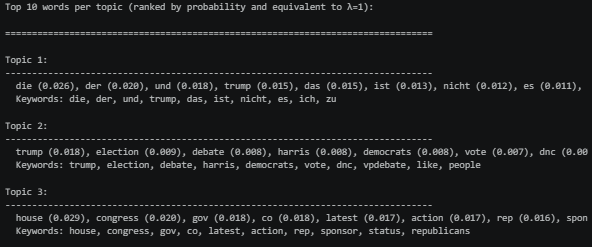

This was the output of LDA topic modeling when non-English rows were not filtered. German was a prominent topic, therefore we use the properly filtered (only english) dataset from Bluesky Silver map (made in **2.2_textual_analysis.ipynb** notebook)

In [3]:
import os
import sys
import time
import re
import string
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Navigate to project root so Data/ paths resolve correctly
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# House style
from house_style import *
apply_style()

# LDA
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

from sklearn.feature_extraction.text import CountVectorizer

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

BUZZ_COLORS = {"TrumpBuzz": REPUBLICAN, "HarrisBuzz": DEMOCRAT, "ElectionBuzz": NEUTRAL}

print(f"Working directory: {os.getcwd()}")
print("Libraries imported successfully!")

Working directory: c:\Users\ninav\OneDrive - UGent\Unif\2025-2026\Semester 2\Social Media and Web Analytics\group-project-SMWA
Libraries imported successfully!


In [4]:
df_clean = pd.read_csv('./Data/2_Silver/Bluesky/cleaned_data.csv', parse_dates=['date'])
df_clean['date']      = pd.to_datetime(df_clean['date']).dt.normalize()
df_clean['text_norm'] = df_clean['text_norm'].fillna('')
df_clean['text']      = df_clean['text'].fillna('')

if 'buzz_group' not in df_clean.columns:
    def assign_buzz(t):
        t = str(t).lower()
        if 'trump'  in t: return 'TrumpBuzz'
        if 'harris' in t: return 'HarrisBuzz'
        return 'ElectionBuzz'
    df_clean['buzz_group'] = df_clean['text_norm'].apply(assign_buzz)

print(f'✓ Loaded {len(df_clean):,} rows  |  {df_clean["date"].min().date()} → {df_clean["date"].max().date()}')
print(df_clean['buzz_group'].value_counts())

✓ Loaded 25,472 rows  |  2024-07-05 → 2024-11-04
buzz_group
ElectionBuzz    12642
TrumpBuzz       10133
HarrisBuzz       2697
Name: count, dtype: int64


##  1 : Preprocessing

- **LDA**: `text_norm` is already cleaned — we just tokenise and filter short tokens

In [5]:
# LDA preprocessing 

def preprocess_for_lda(text):
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = word_tokenize(text.lower())
    # Add domain-specific stops on top of already-cleaned text
    extra_stops = {}
    tokens = [w for w in tokens if w.isalpha() and len(w) > 2 and w not in extra_stops]
    return tokens

# BERTopic preprocessing
def preprocess_for_bertopic(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = ' '.join(text.split())
    return text

print('Applying LDA preprocessing on text_norm...')
start = time.time()
df_clean['tokens_lda'] = df_clean['text_norm'].apply(preprocess_for_lda)
print(f'✓ LDA preprocessing done in {time.time()-start:.1f}s')

print('Applying BERTopic preprocessing on text...')
start = time.time()
df_clean['text_bertopic'] = df_clean['text'].apply(preprocess_for_bertopic)
print(f'✓ BERTopic preprocessing done in {time.time()-start:.1f}s')

df_lda      = df_clean[df_clean['tokens_lda'].apply(len) > 0].copy().reset_index(drop=True)
df_bertopic = df_clean[df_clean['text_bertopic'].str.len() > 10].copy().reset_index(drop=True)

print(f'\n✓ LDA documents:      {len(df_lda):,}')
print(f'✓ BERTopic documents: {len(df_bertopic):,}')

# Show example
print('\n' + '='*60)
print('PREPROCESSING EXAMPLE')
print('='*60)
print('\nOriginal text:')
print(df_clean['text'].iloc[0][:200])
print('\nLDA tokens (from text_norm):')
print(df_clean['tokens_lda'].iloc[0][:20])
print('\nBERTopic input (from text):')
print(df_clean['text_bertopic'].iloc[0][:200])

Applying LDA preprocessing on text_norm...
✓ LDA preprocessing done in 2.1s
Applying BERTopic preprocessing on text...
✓ BERTopic preprocessing done in 0.3s

✓ LDA documents:      25,367
✓ BERTopic documents: 25,342

PREPROCESSING EXAMPLE

Original text:
In 1970, the Club of Rome predicted a crash early in this century. So far, their predictions have tracked pretty well. Maybe the worldwide drop in living standards is the first hint that the crash is 

LDA tokens (from text_norm):
['club', 'rome', 'predicted', 'crash', 'early', 'century', 'far', 'predictions', 'tracked', 'pretty', 'well', 'maybe', 'worldwide', 'drop', 'living', 'first', 'hint', 'crash', 'coming', 'trump']

BERTopic input (from text):
In 1970, the Club of Rome predicted a crash early in this century. So far, their predictions have tracked pretty well. Maybe the worldwide drop in living standards is the first hint that the crash is 


## 2 : LDA — Build Dictionary & Corpus

In [6]:
print('Creating document-term matrix for LDA...')

tokenized_docs = df_lda['tokens_lda'].tolist()

dictionary = corpora.Dictionary(tokenized_docs)
print(f'Original vocabulary size: {len(dictionary):,}')

# Filter extremes: word must appear in ≥5 docs and ≤50% of docs
dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f'Filtered vocabulary size: {len(dictionary):,}')

corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]
print(f'✓ Corpus: {len(corpus):,} documents')

Creating document-term matrix for LDA...
Original vocabulary size: 26,160
Filtered vocabulary size: 7,623
✓ Corpus: 25,367 documents


## 3 : LDA — Coherence Score and AIC: choosing optimal topic amount

In [7]:
print('Testing different numbers of topics for LDA...')

coherence_scores_lda = []
aic_scores_lda       = []
topic_range          = range(2, 11)
lda_start            = time.time()

for num_topics in topic_range:
    print(f'  Training LDA with {num_topics} topics...')
    lda = LdaModel(
        corpus=corpus, id2word=dictionary,
        num_topics=num_topics, random_state=42,
        passes=10, alpha='auto', per_word_topics=True
    )

    # Coherence
    cm = CoherenceModel(model=lda, corpus=corpus,
                        dictionary=dictionary, coherence='u_mass')
    score = cm.get_coherence()
    coherence_scores_lda.append(score)

    # AIC
    log_likelihood = lda.log_perplexity(corpus) * len(corpus)
    num_params     = num_topics * len(dictionary)
    aic            = -2 * log_likelihood + 2 * num_params
    aic_scores_lda.append(aic)

    print(f'    Coherence (u_mass): {score:.4f}  |  AIC: {aic:.2f}')

print(f'\n✓ Sweep completed in {(time.time()-lda_start)/60:.1f} minutes')

Testing different numbers of topics for LDA...
  Training LDA with 2 topics...
    Coherence (u_mass): -3.2989  |  AIC: 411591.53
  Training LDA with 3 topics...
    Coherence (u_mass): -2.8183  |  AIC: 424832.25
  Training LDA with 4 topics...
    Coherence (u_mass): -3.0053  |  AIC: 440435.75
  Training LDA with 5 topics...
    Coherence (u_mass): -3.3932  |  AIC: 457446.15
  Training LDA with 6 topics...
    Coherence (u_mass): -4.5198  |  AIC: 473479.87
  Training LDA with 7 topics...
    Coherence (u_mass): -6.7656  |  AIC: 489329.21
  Training LDA with 8 topics...
    Coherence (u_mass): -6.6998  |  AIC: 504709.79
  Training LDA with 9 topics...
    Coherence (u_mass): -7.2709  |  AIC: 520511.88
  Training LDA with 10 topics...
    Coherence (u_mass): -6.7003  |  AIC: 538857.98

✓ Sweep completed in 4.9 minutes


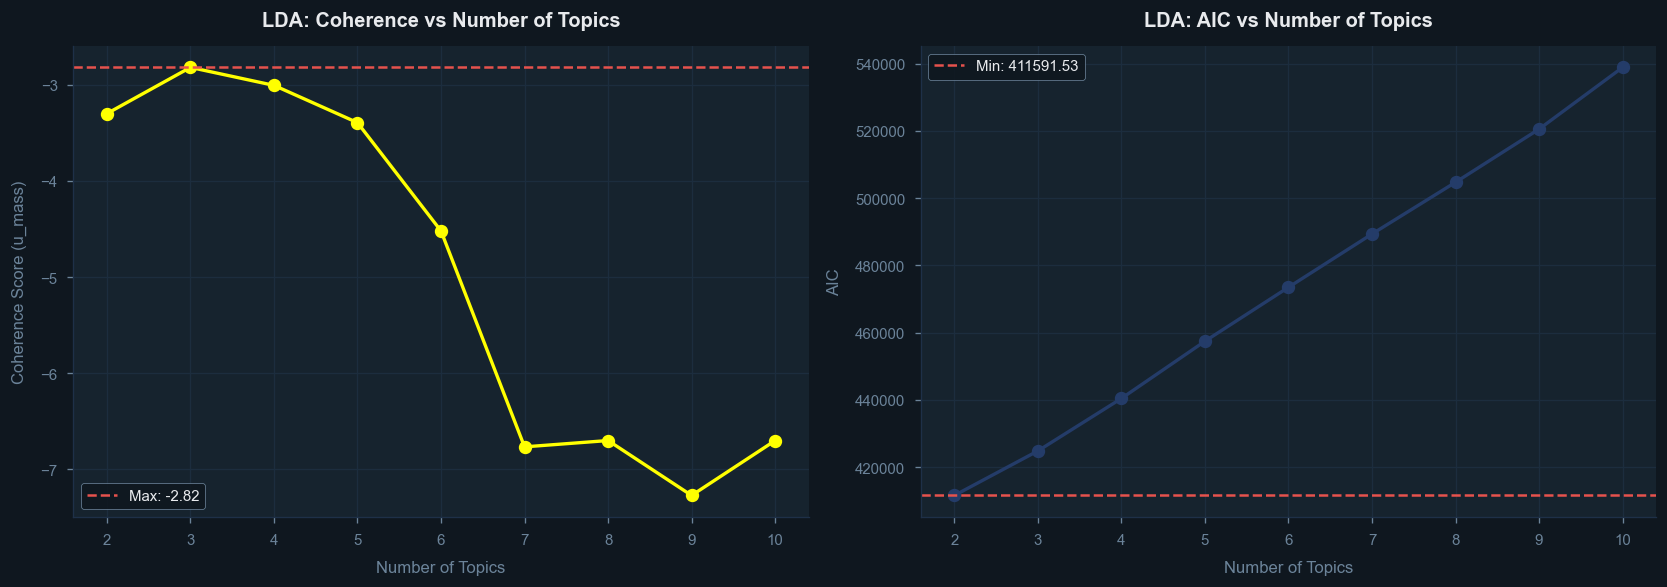


✓ Optimal number of topics (coherence): 3
  Coherence: -2.8183
  AIC at optimal: 424832.25


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)

for ax, scores, ylabel, title, color in [
    (ax1, coherence_scores_lda, 'Coherence Score (u_mass)', 'LDA: Coherence vs Number of Topics', '#FFFF00'),
    (ax2, aic_scores_lda,       'AIC',                      'LDA: AIC vs Number of Topics',       ACCENT),
]:
    ax.set_facecolor(BG_PANEL)
    ax.plot(list(topic_range), scores, marker='o', color=color, linewidth=2, markersize=7)
    best_val = max(scores) if 'Coherence' in ylabel else min(scores)
    ax.axhline(best_val, color=REPUBLICAN, lw=1.5, ls='--',
               label=f'{"Max" if "Coherence" in ylabel else "Min"}: {best_val:.2f}')
    ax.set_xlabel('Number of Topics', color=TEXT_MUTED, fontsize=10)
    ax.set_ylabel(ylabel, color=TEXT_MUTED, fontsize=10)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED)
    ax.legend(fontsize=9, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.savefig('lda_coherence_sweep.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

optimal_topics_lda = list(topic_range)[np.argmax(coherence_scores_lda)]
print(f'\n✓ Optimal number of topics (coherence): {optimal_topics_lda}')
print(f'  Coherence: {max(coherence_scores_lda):.4f}')
print(f'  AIC at optimal: {aic_scores_lda[list(topic_range).index(optimal_topics_lda)]:.2f}')

## 4 : LDA — Train Final Model

In [9]:
print(f'Training final LDA model with {optimal_topics_lda} topics...')

lda_train_start = time.time()
lda_model = LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=optimal_topics_lda, random_state=42,
    passes=15, iterations=400,
    alpha='auto', eta='auto', per_word_topics=True
)
lda_train_time = time.time() - lda_train_start

print(f'✓ LDA trained in {lda_train_time:.1f}s')

cm_final = CoherenceModel(model=lda_model, texts=tokenized_docs,
                          dictionary=dictionary, coherence='u_mass')
coherence_lda_final = cm_final.get_coherence()
print(f'✓ Final LDA Coherence (u_mass): {coherence_lda_final:.4f}')

Training final LDA model with 3 topics...
✓ LDA trained in 41.1s
✓ Final LDA Coherence (u_mass): -2.7045


In [10]:
lda_topics = []
print('\n' + '='*80)
print('LDA TOPIC SUMMARY (Top 10 Words)')
print('='*80)

for i in range(lda_model.num_topics):
    words = [word for word, _ in lda_model.show_topic(i, topn=10)]
    lda_topics.append(words)
    print(f'\nLDA Topic {i}: {", ".join(words)}')


LDA TOPIC SUMMARY (Top 10 Words)

LDA Topic 0: house, sky, social, latest, action, congress, rep, gov, sponsor, status

LDA Topic 1: election, harris, vote, kamalaharris, politics, harriswalz, kamala, democrats, voteblue, day

LDA Topic 2: trump, maga, donaldtrump, republicans, gop, debate, like, people, donald, election


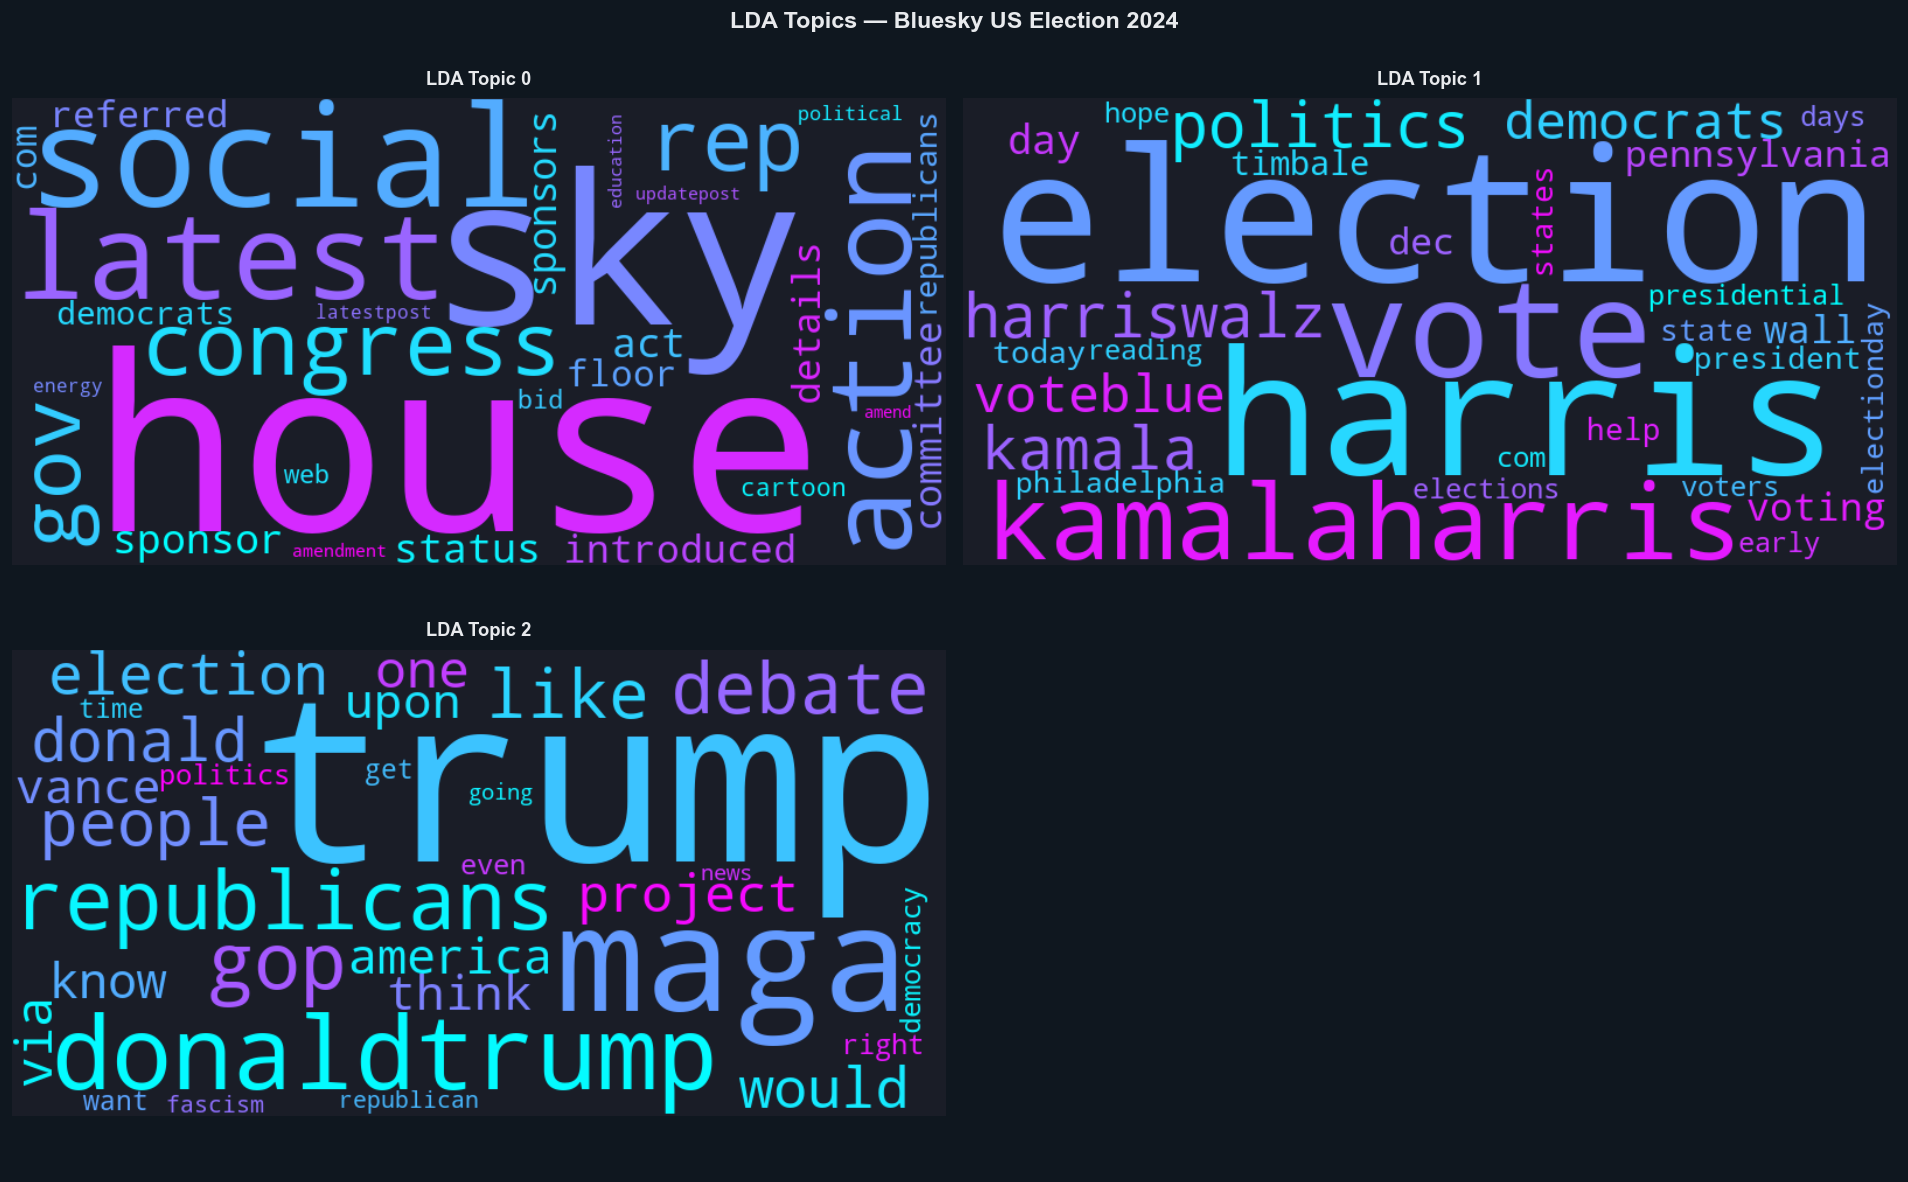

In [11]:
from wordcloud import WordCloud

n_topics_lda = lda_model.num_topics
n_cols = 2
n_rows = (n_topics_lda + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
fig.patch.set_facecolor(BG_DARK)
axes = axes.flatten()

for topic_id in range(n_topics_lda):
    topic_data = lda_model.show_topic(topic_id, topn=30)
    word_weights = {word: weight for word, weight in topic_data}

    wc = WordCloud(
        width=800, height=400,
        background_color='#1a1d27',
        colormap='cool',
        max_words=30,
        prefer_horizontal=0.9
    ).generate_from_frequencies(word_weights)

    ax = axes[topic_id]
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'LDA Topic {topic_id}', color=TEXT_PRIMARY,
                 fontweight='bold', fontsize=11, pad=8)

for i in range(n_topics_lda, len(axes)):
    axes[i].axis('off')

fig.suptitle('LDA Topics — Bluesky US Election 2024',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lda_topics_wordcloud.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

In [12]:
EVENTS = [
    {'label': 'Trump Shot',      'date': pd.Timestamp('2024-07-13')},
    {'label': 'Biden Drops Out', 'date': pd.Timestamp('2024-07-21')},
    {'label': 'Debate',          'date': pd.Timestamp('2024-09-10')},
    {'label': 'Golf Attempt',    'date': pd.Timestamp('2024-09-15')},
]

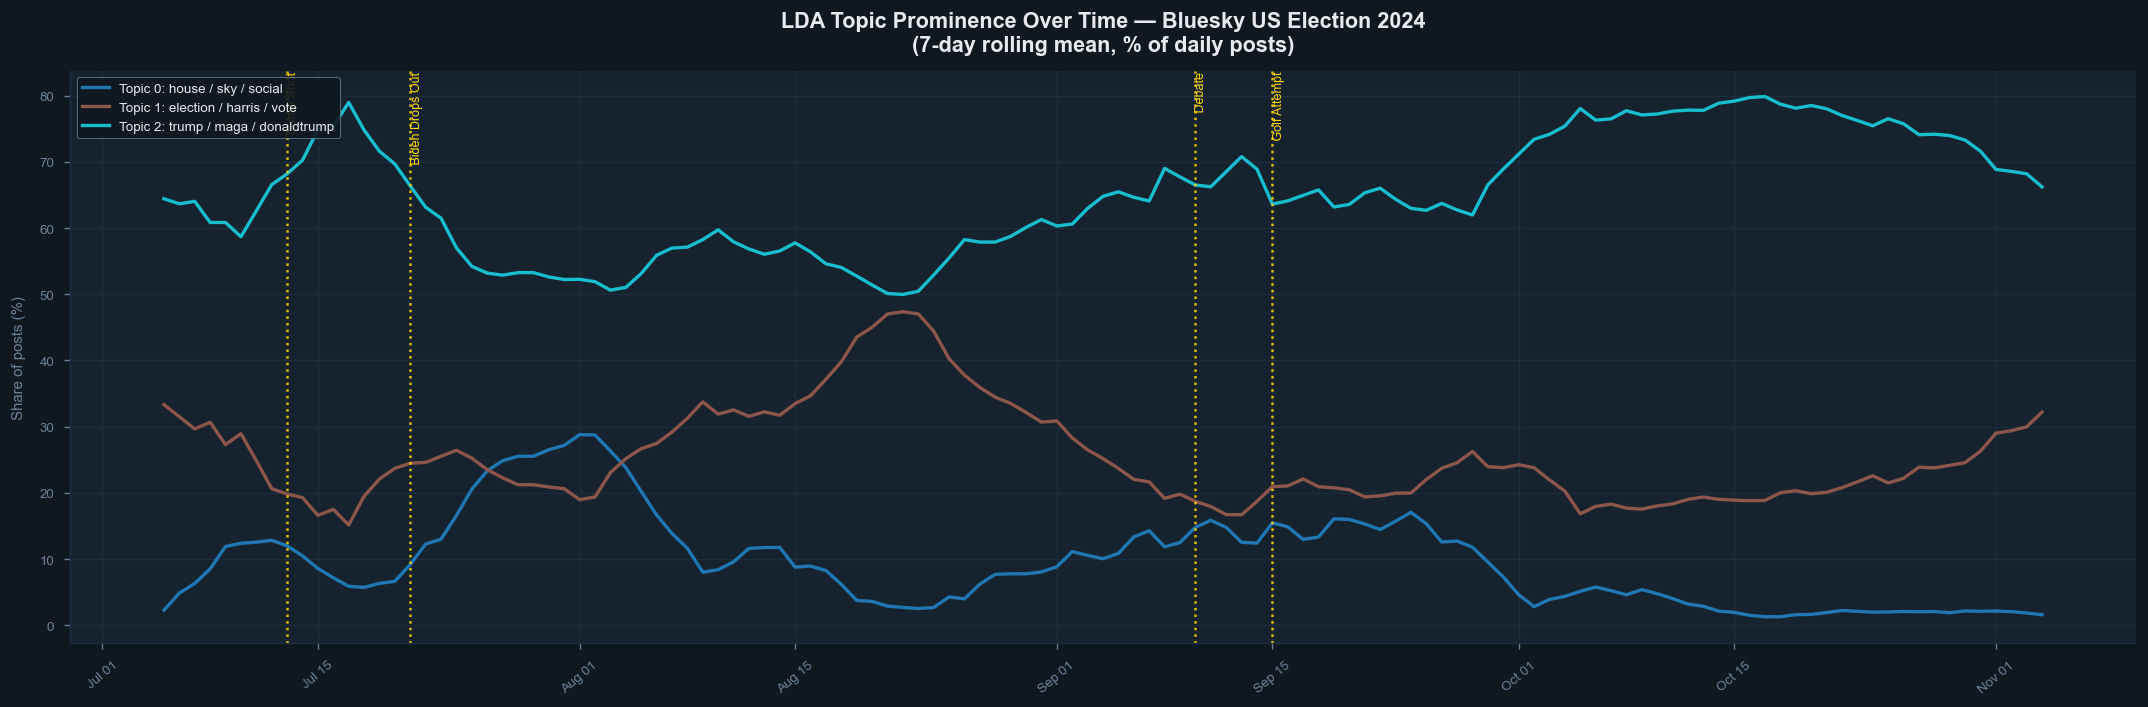

In [13]:
# ── Assign dominant LDA topic to each post ───────────────────────────────────
def get_dominant_topic_lda(ldamodel, corpus):
    dominant = []
    for doc in corpus:
        dist = ldamodel.get_document_topics(doc)
        dominant.append(sorted(dist, key=lambda x: x[1], reverse=True)[0][0] if dist else -1)
    return dominant

df_lda['lda_topic'] = get_dominant_topic_lda(lda_model, corpus)

# ── Topic labels from top 3 words ────────────────────────────────────────────
topic_labels = {
    i: ' / '.join([w for w, _ in lda_model.show_topic(i, topn=3)])
    for i in range(lda_model.num_topics)
}

# ── Daily topic share ─────────────────────────────────────────────────────────
daily_topic_counts = (
    df_lda.groupby(['date', 'lda_topic'])
    .size()
    .reset_index(name='post_count')
)
daily_totals = df_lda.groupby('date').size().reset_index(name='total')
daily_topic_counts = daily_topic_counts.merge(daily_totals, on='date')
daily_topic_counts['share'] = daily_topic_counts['post_count'] / daily_topic_counts['total'] * 100

topic_share_pivot = (
    daily_topic_counts
    .pivot(index='date', columns='lda_topic', values='share')
    .fillna(0)
)
topic_share_pivot.index = pd.to_datetime(topic_share_pivot.index)
topic_share_pivot = topic_share_pivot.sort_index()

# ── Plot ──────────────────────────────────────────────────────────────────────
topic_palette = plt.cm.tab10(np.linspace(0, 1, lda_model.num_topics))

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for topic_id in topic_share_pivot.columns:
    smooth = topic_share_pivot[topic_id].rolling(7, center=True, min_periods=3).mean()
    ax.plot(
        topic_share_pivot.index, smooth,
        label=f'Topic {topic_id}: {topic_labels[topic_id]}',
        linewidth=2, color=topic_palette[topic_id]
    )

# Event markers
for ev in EVENTS:
    ax.axvline(ev['date'], color='#FFD700', lw=1.5, ls=':', alpha=0.85)
    ax.text(ev['date'], ax.get_ylim()[1], f" {ev['label']}",
            color='#FFD700', fontsize=7.5, va='top', rotation=90)

ax.set_title('LDA Topic Prominence Over Time — Bluesky US Election 2024\n(7-day rolling mean, % of daily posts)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.set_ylabel('Share of posts (%)', color=TEXT_MUTED, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=8)
ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=8)
ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
          labelcolor=TEXT_PRIMARY, loc='upper left')

plt.tight_layout()
plt.savefig('lda_topic_over_time.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()


# Topic per buzz group

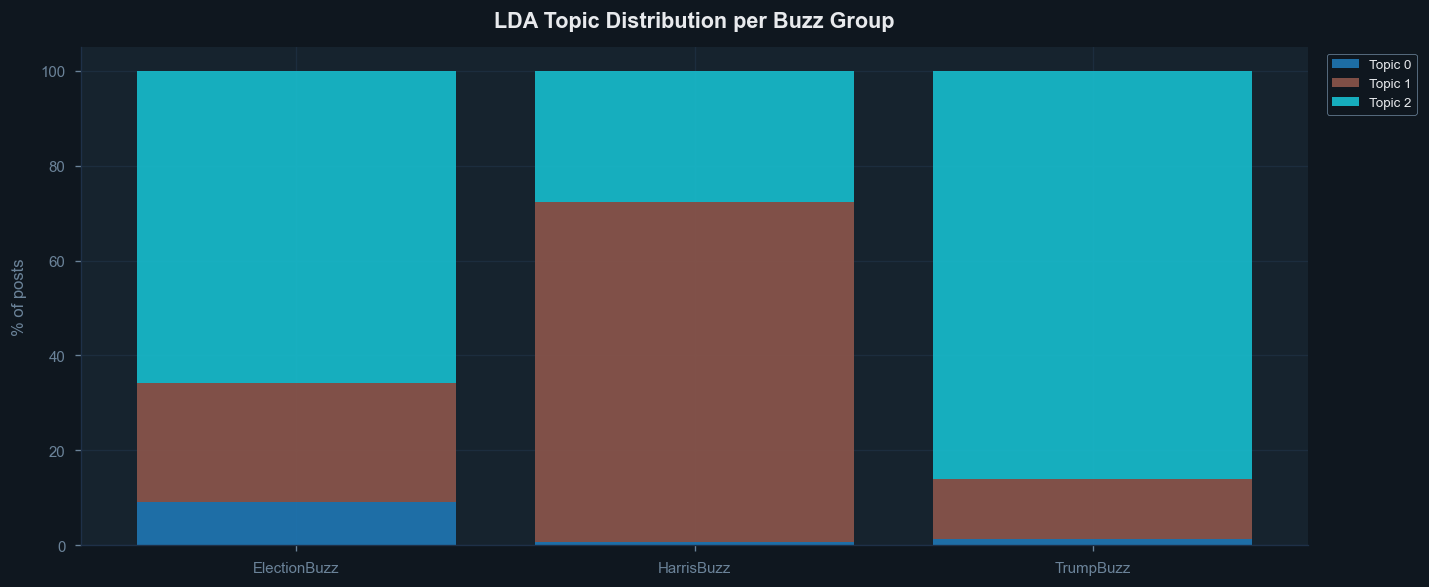

In [14]:
# Merge LDA topic assignments back with buzz_group
lda_buzz = df_lda.groupby(['buzz_group', 'lda_topic']).size().unstack(fill_value=0)
lda_buzz_pct = lda_buzz.div(lda_buzz.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

topic_palette = plt.cm.tab10(np.linspace(0, 1, lda_model.num_topics))

bottom = np.zeros(len(lda_buzz_pct))
for i, col in enumerate(lda_buzz_pct.columns):
    ax.bar(lda_buzz_pct.index, lda_buzz_pct[col],
           bottom=bottom, label=f'Topic {col}',
           color=topic_palette[i], edgecolor='none', alpha=0.9)
    bottom += lda_buzz_pct[col].values

ax.set_ylabel('% of posts', color=TEXT_MUTED, fontsize=10)
ax.set_title('LDA Topic Distribution per Buzz Group',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.tick_params(colors=TEXT_MUTED, labelsize=9)
ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED,
          labelcolor=TEXT_PRIMARY, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('lda_topic_by_buzz.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()